# Discrétisation d'une EDS: erreur faible

Soit $(x_t)_{t \in [0,T]}$ solution d'une EDS 
\begin{equation*}
    \operatorname{d}\! x_t = b(x_t) \operatorname{d}\! t + \sigma(x_t) \operatorname{d}\! W_t, \quad x_0 \in \mathbf{R^d}.
\end{equation*}
On se donne des instants de discrétisation $0=t_0 < t_1 < \dots < t_N = T$ et dans la suite on spécifie la grille homogène $t_n = n \frac{T}{N} = n h$ avec $h = \frac{T}{N}$ appelé le pas de discrétisation.

**Schéma d'Euler**   
On rappelle le schéma d'Euler pour une diffusion:
\begin{equation*}
    X_{t_{n+1}} = X_{t_n} + b(X_{t_n}) h + \sigma(X_{t_n}) \sqrt{h} G_{n+1}, \quad X_0 = x_0.
\end{equation*}
où dans toute la suite $(G_1,\dots,G_N)$ est un vecteur Gaussien centré réduit (composantes indépendantes). La loi de $\sqrt{h} G_{n+1}$ est celle de l'accroissement $W_{t_{n+1}} - W_{t_n}$.

**Schéma de Milstein**  
Avec les mêmes notations que précédemment on définit le schéma de Milstein pour une diffusion (en dimension 1):
\begin{equation*}
    X_{t_{n+1}} = X_{t_n} + b(X_{t_n}) h + \sigma(X_{t_n}) \sqrt{h} G_{n+1} + \frac{1}{2} (\sigma \sigma')(X_{t_n})(G_{n+1}^2 - 1) h.
\end{equation*}

In [11]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 
from numpy.random import default_rng
rng = default_rng()

## Diffusion Black-Scholes comme "benchmark"

L'équation différentielle stochastique (EDS) est donnée par 
\begin{equation*}
    \operatorname{d}\! x_t = r x_t \operatorname{d}\! t + \sigma x_t \operatorname{d}\! W_t, \quad x_0 > 0
\end{equation*}

**Rappel:** Pour Black-Scholes on connaît la vraie solution 
\begin{equation*}
    \forall t \in [0,T], \quad x_t = x_0 e^{\left(r - \frac{\sigma^2}{2} \right) t + \sigma W_t}.
\end{equation*}

In [12]:
class BlackScholes:
    def __init__(self, x0, r, sigma, T):
        self.x0 = x0
        self.r = r
        self.sigma = sigma
        self.T = T        
    def paths_exact(self, dW):
        N, M = dW.shape
        h = self.T / N
        x = np.empty(shape=(N+1,M))
        x[0] = self.x0
        for n in range(1, N+1): 
            x[n] = x[n-1] * np.exp((self.r - 0.5 * self.sigma**2) * h + self.sigma * dW[n-1])
        # on pourrait utiliser np.cumprod à la place de cette boucle...
        return x
    def paths_euler(self, dW):
        N, M = dW.shape
        h = self.T / N
        X = np.empty(shape=(N+1,M))
        X[0] = self.x0
        for n in range(1, N+1):
            X[n] = X[n-1] + self.r * X[n-1] * h + self.sigma * X[n-1] * dW[n-1]
        return X
    def paths_milstein(self, dW):
        N, M = dW.shape
        h = self.T / N 
        X = np.empty(shape=(N+1,M))
        X[0] = self.x0
        for n in range(1, N+1):
            X[n] = X[n-1] + self.r * X[n-1] * h +\
                    self.sigma * X[n-1] * dW[n-1] +\
                    0.5 * self.sigma**2 * X[n-1] * (dW[n-1]**2-h)
        return X

In [13]:
X = BlackScholes(x0=100, r=0.2, sigma=0.3, T=1)
N, M = 20, 15
dW = np.sqrt(X.T / N) * rng.standard_normal((N, M))

In [14]:
X.paths_exact(dW)[-1] # les valeurs terminales en T des 15 actifs

array([119.46156536, 130.46437367, 123.55201175, 113.76734568,
       126.21435506,  57.61536451,  88.82867419, 220.3396059 ,
       148.36240909, 110.81700528,  75.3313825 , 174.08950571,
       137.05828578, 109.78925138,  87.95078526])

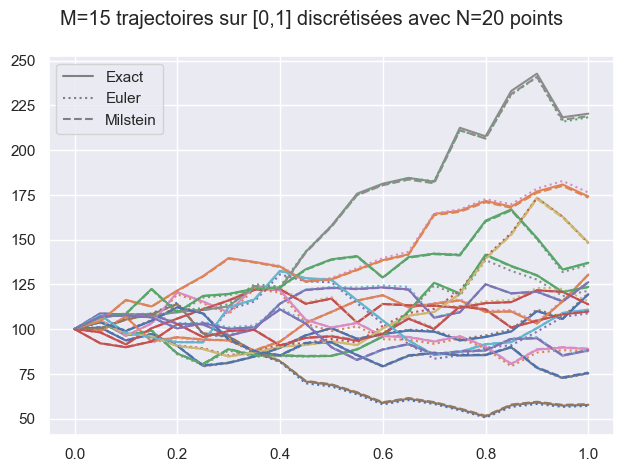

In [15]:
from matplotlib.lines import Line2D
tt = np.linspace(0, X.T, N+1)
fig, ax = plt.subplots(layout='tight')

ax.plot(tt, X.paths_exact(dW))
ax.plot(tt, X.paths_euler(dW), linestyle='dotted')
ax.plot(tt, X.paths_milstein(dW), linestyle='dashed')

legend_elements = [Line2D([0], [0], color='grey', label='Exact'),
                   Line2D([0], [0], color='grey', linestyle='dotted', label='Euler'),
                   Line2D([0], [0], color='grey', linestyle='dashed', label='Milstein')]
ax.legend(handles=legend_elements, loc='upper left')

fig.suptitle(fr'M={M} trajectoires sur [0,{X.T}] discrétisées avec N={N} points')
plt.show()

## Erreur faible

On rappelle que l'erreur faible entre la diffusion $\bigl(x_t\bigr)_{t \in [0,T]}$ et un schéma numérique $\bigl(X^N_{k}\bigr)_{k=0,\dots, N}$ le long d'une fonction $\varphi$ vérifie le développement suivant
\begin{equation*}
    \exists c_1, \dots, c_R, \qquad \mathbb{E} \bigl[ \varphi(x_T) \bigr]
    - \mathbb{E} \bigl[ \varphi(X^N_N) \bigr] = \frac{c_1}{N} + \frac{c_2}{N^2} + \cdots + \frac{c_R}{N^R} + \mathcal{O}\bigl( \frac{1}{N^R} \bigr)
\end{equation*}

Le but est d'illustrer numériquement une partie de ce résultat.

On illustre les résultats de convergence de l'erreur faible du schéma d'Euler et de Milstein dans le cas d'un pricing d'un call de strike $K$ à maturité $T$. Ainsi on a 
\begin{equation*}
    \operatorname{d}\! x_t = r x_t \operatorname{d}\! t 
    + \sigma x_t \operatorname{d}\! W_t, \quad x_0 > 0,
\end{equation*}
et 
\begin{equation*}
    P_{Call}(K) = e^{-r T} \mathbb{E}\bigl[ (x_T - K)_+ \bigr] = 
    x_0 \phi(d_1) - K e^{-r T} \phi(d_2)
\end{equation*}
avec $d_1 = \frac{ \log(S_0 / K) + (r+\sigma^2/2) T}{\sigma \sqrt{T}}$, $d_2 = d_1 - \sigma \sqrt{T}$, et $\phi$ la fonction de répartition d'une loi $\mathcal{N}(0,1)$.

### Question: pricing du call Black-Scholes 

Ecrire une fonction `bs_call(X, K)` qui calcule le prix d'un call de strike `K` d'un objet `X` de classe Black-Scholes. On rappelle que l'objet `X` contient les paramètres de la maturité $T$, le taux $r$, la volatilité $\sigma$ et la condition initiale $x_0$).  
Dans la suite on prend $r=0.2$, $\sigma=0.3$, $T=1$ et $K = x_0 = 100$.

In [17]:
X = BlackScholes(x0=100, r=0.2, sigma=0.3, T=1)
def bs_call(X : BlackScholes, K):
    d1 = (np.log(X.x0/K) + (X.r + 0.5 * X.sigma**2) * X.T) / (X.sigma * np.sqrt(X.T))
    d2 = d1 - X.sigma * np.sqrt(X.T)
    return X.x0 * stats.norm.cdf(d1) - K * np.exp(-X.r * X.T) * stats.norm.cdf(d2)

exact_price = bs_call(X, K=100)
print(f'Prix exact de l\'option : {exact_price:.4f}')

Prix exact de l'option : 22.2035


### Question: vérification du code, pricing Monte Carlo

Faire un code Monte Carlo pour vérifier le prix obtenu en utilisant la méthode `paths_exact` de l'objet `X`.

In [25]:
def monte_carlo_call_price(X : BlackScholes, K, N, M):
    dW = np.sqrt(X.T / N) * rng.standard_normal((N, M))
    S_T = X.paths_exact(dW)[-1]
    payoff = np.maximum(S_T - K, 0)
    price = np.exp(-X.r * X.T) * np.mean(payoff)
    stdev = np.exp(-X.r * X.T) * np.std(payoff) / np.sqrt(M)
    return price, stdev

N, M = 1000, 10000
estimated_price, estimated_stdev = monte_carlo_call_price(X, K=100, N=N, M=M)
print(f'Prix estimé de l\'option par Monte Carlo : {estimated_price:.4f} ± {estimated_stdev:.4f}')

Prix estimé de l'option par Monte Carlo : 21.9049 ± 0.2622


### Question: estimation de l'erreur faible 

Ecrire une fonction `compute_call_bs(sde, scheme, N, M = 10000)` qui fait un code de Monte Carlo à partir de $M$ simulations d'un schéma de discrétisation (`scheme` est `"euler"` ou `"milstein"`) d'un nombre de pas de temps $N$. Le premier argument `sde` est un objet de la classe `BlackScholes`.

Tester votre code en calculant le prix Monte Carlo biaisé en utilisant le schéma d'Euler puis du schéma de Milstein et en faisant varier $N$ de 2 à 128.

Que peut-on dire des prix obtenus ? et des intervalles de confiances associés ? 

Prix estimé de l'option par exact : 21.9850 ± 0.2604
Prix estimé de l'option par euler : 22.0199 ± 0.2598
Prix estimé de l'option par milstein : 22.1095 ± 0.2594


,exact price ± stdev,euler price ± stdev,milstein price ± stdev
2,"(22.114586560149707, 0.26304423938105465)","(21.04742560195535, 0.22273038247582966)","(20.5474759176418, 0.23770194210943096)"
4,"(22.204491226446354, 0.26316185331633996)","(21.513151953767018, 0.24047958560055768)","(21.011648370594155, 0.24441438202360846)"
8,"(22.54624028907915, 0.2696586514752491)","(22.14710901421763, 0.25513729407637337)","(21.732833835575992, 0.2538647106676578)"
16,"(22.30695116296572, 0.2667872526957249)","(21.53481682185777, 0.2536309233467119)","(22.151781908217394, 0.2612206999256248)"
32,"(22.359634680337713, 0.26728940853832844)","(22.531500458802654, 0.26453199317491916)","(22.312647601644972, 0.2620479080486166)"
64,"(22.16986753012122, 0.261740117596332)","(21.63902290667206, 0.25738097400265275)","(21.792986785787594, 0.262286589972619)"
128,"(22.594202421855744, 0.2636929667449982)","(22.211646309940463, 0.26360002351366213)","(21.851706217418915, 0.26031469897088527)"


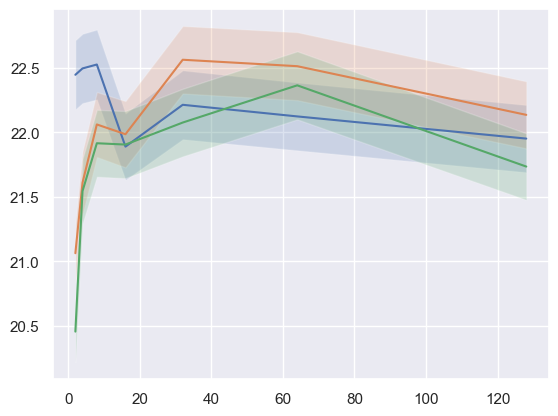

In [35]:
import pandas as pd
def compute_call_bs(sde : BlackScholes, scheme, N, M):
    dW = np.sqrt(sde.T / N) * rng.standard_normal((N, M))
    if scheme == 'exact':
        S_T = sde.paths_exact(dW)[-1]
    elif scheme == 'euler':
        S_T = sde.paths_euler(dW)[-1]
    elif scheme == 'milstein':
        S_T = sde.paths_milstein(dW)[-1]
    else:
        raise ValueError("Scheme must be 'exact', 'euler' or 'milstein'")
    payoff = np.maximum(S_T - 100, 0)
    price = np.exp(-sde.r * sde.T) * np.mean(payoff)
    stdev = np.exp(-sde.r * sde.T) * np.std(payoff) / np.sqrt(M)
    return price, stdev

schemes = ['exact', 'euler', 'milstein']
prices = [compute_call_bs(X, scheme, N, M) for scheme in schemes]
for scheme, price in zip(schemes, prices):
    print(f'Prix estimé de l\'option par {scheme} : {price[0]:.4f} ± {price[1]:.4f}')

N_list = [2**i for i in range(1, 8)]


for scheme in schemes:
    prices = [compute_call_bs(X, scheme, N, M) for N in N_list]
    plt.plot(N_list, [p[0] for p in prices], label=scheme)
    plt.fill_between(N_list, [p[0] - p[1] for p in prices], [p[0] + p[1] for p in prices], alpha=0.2, label=scheme)

result = pd.DataFrame({scheme: [compute_call_bs(X, scheme, N, M) for N in N_list] for scheme in schemes}, index=N_list)
result.columns = [f'{scheme} price ± stdev' for scheme in schemes]

### Question: visualisation

Tracer les erreurs et les zones de confiances associées en fonction de $h = \frac{1}{N}$ pour les 2 schémas de discrétisation.

## Extrapolation de Richardson

L'extrapolation de Richardson est une technique permettant de gagner un ordre de convergence. En effet, en considérant une combinaison linéaire entre un schéma de pas $\frac{T}{N}$ et un autre de pas $\frac{T}{2N}$ on peut améliorer l'ordre de convergence en éliminant le premier terme $\frac{c_1}{N}$ qui apparait dans le développement de l'erreur faible:
\begin{equation*}
    \mathbb{E} \bigl[ \varphi(x_T) \bigr]
    - \mathbb{E} \bigl[ 2 \varphi(X^{2N}_{2N}) -  \varphi(X^{N}_{N}) \bigr] = -\frac{c_2}{2 N^2} + \mathcal{O}\bigl( \frac{1}{N^2} \bigr)
\end{equation*}

### Question: estimation avec extrapolation

Ecrire une fonction `compute_call_bs_richardson` similaire à `compute_call_bs` qui est un estimateur Monte Carlo de 
\begin{equation*}
\mathbb{E} \bigl[ 2 \varphi(X^{2N}_{2N}) -  \varphi(X^{N}_{N}) \bigr]
\end{equation*}

In [36]:
def compute_call_bs_richardson(sde : BlackScholes, scheme, N, M):
    dW_fine = np.sqrt(sde.T / N) * rng.standard_normal((N, M))
    dW_coarse = dW_fine[::2, :] + dW_fine[1::2, :]
    if scheme == 'exact':
        paths_fine = sde.paths_exact(dW_fine)
        paths_coarse = sde.paths_exact(dW_coarse)
    elif scheme == 'euler':
        paths_fine = sde.paths_euler(dW_fine)
        paths_coarse = sde.paths_euler(dW_coarse)
    elif scheme == 'milstein':
        paths_fine = sde.paths_milstein(dW_fine)
        paths_coarse = sde.paths_milstein(dW_coarse)
    else:
        raise ValueError("Scheme must be 'exact', 'euler' or 'milstein'")
    payoff_fine = np.maximum(paths_fine[-1] - 100, 0)
    payoff_coarse = np.maximum(paths_coarse[-1] - 100, 0)
    price = np.exp(-sde.r * sde.T) * (2 * np.mean(payoff_fine) - np.mean(payoff_coarse))
    stdev = np.exp(-sde.r * sde.T) * np.std(payoff_fine - payoff_coarse) / np.sqrt(M)
    return price, stdev

### Question: estimation et visualisation

Reprendre l'étude précédente pour comparer les méthodes avec et sans extrapolation de Richardson-Romberg.

In [39]:
Ns = 2**np.arange(1, 8)
res_euler = [compute_call_bs_richardson(X, 'euler', N, M) for N in Ns]
res_euler_df = pd.DataFrame({'N': Ns, 'Euler price ± stdev': res_euler})

In [41]:
import pandas as pd
import numpy as np
import ast

col = "Euler price ± stdev"

# If the tuples are stored as strings (sometimes happens), convert safely to real tuples
res_euler_df[col] = res_euler_df[col].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Split (price, stdev) into two columns
tmp = res_euler_df[col].apply(pd.Series)
tmp.columns = ["price", "stdev"]

# Build output dataframe
df_out = pd.concat([res_euler_df[["N"]], tmp], axis=1)

# Bounds: choose either 1-sigma or 95% CI (z=1.96)
df_out["lower_1sigma"] = df_out["price"] - df_out["stdev"]
df_out["upper_1sigma"] = df_out["price"] + df_out["stdev"]

z = 1.96
df_out["lower_95"] = df_out["price"] - z * df_out["stdev"]
df_out["upper_95"] = df_out["price"] + z * df_out["stdev"]

df_out

,N,price,stdev,lower_1sigma,upper_1sigma,lower_95,upper_95
0,2,22.622014,0.040019,22.581995,22.662033,22.543576,22.700452
1,4,22.450015,0.029403,22.420612,22.479417,22.392385,22.507644
2,8,22.066634,0.021375,22.045259,22.088009,22.024738,22.108529
3,16,22.619715,0.015216,22.604499,22.634931,22.589892,22.649539
4,32,22.136467,0.011026,22.125441,22.147492,22.114856,22.158077
5,64,22.668339,0.007760,22.660580,22.676099,22.653130,22.683549
6,128,22.465535,0.005447,22.460088,22.470982,22.454859,22.476211
